# GSE161332 Leaf Reference Transfer Test

## tl;dr

This notebook summarizes and visualizes the first Arabidopsis leaf-reference test using `GSE161332`.

Key result from the local model test:

- `GSE161332` contains all `340 / 340` frozen root-consensus model features, so the dataset is technically compatible with the current model.
- The frozen root-derived model accepted `1,987 / 6,300` cells (`31.5%`) under the conservative dual-model agreement rule.
- Most cells remained `ambiguous` (`68.5%`), and most accepted labels were `abiotic_stress_response`.
- Conclusion: the root-derived model is useful as a conservative benchmark, but it is not biologically sufficient for leaf-like or Wolffia-like interpretation. A dedicated leaf/aerial reference layer is needed next.

## Context & Methods

### Project context

The current frozen model was trained from a root-derived Arabidopsis benchmark and restricted to `340` Arabidopsis genes with high- or medium-confidence Arabidopsis-to-Wolffia transfer support. It currently predicts only three broad programs:

- `abiotic_stress_response`
- `proliferative_or_meristematic`
- `transport_interface_or_water_balance`

`GSE161332` was selected as the first Arabidopsis leaf reference because it provides processed 10x-style matrix files and contains leaf-relevant cell populations such as mesophyll, epidermal, guard-cell, hydathode, and vascular-associated cells.

### Key assumptions

- The recorded summary values come from the local run of `scripts/33_apply_root_consensus_to_gse161332_leaf.py`.
- Large GEO matrix files and model artifacts are ignored by git, so this notebook includes recorded results for review and optional reproduction code for local reruns.
- The result should be interpreted as a root-model diagnostic on a leaf dataset, not as a final leaf cell-type annotation.

## Data and Reproducibility Setup

The full local reproduction uses these files:

- `data/public_references/raw/GSE161332/GSE161332_matrix.mtx.gz`
- `data/public_references/raw/GSE161332/GSE161332_features.tsv.gz`
- `data/public_references/raw/GSE161332/GSE161332_barcodes.tsv.gz`
- `results/root_reference_consensus_ortholog_restricted/logistic_regression_root_consensus.joblib`
- `results/root_reference_consensus_ortholog_restricted/random_forest_root_consensus.joblib`

The exact command is:

```bash
python scripts/33_apply_root_consensus_to_gse161332_leaf.py
```

In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SUMMARY_PATH = REPO_ROOT / "results/gse161332_leaf_transfer_test/gse161332_leaf_transfer_summary.json"
COUNTS_PATH = REPO_ROOT / "results/gse161332_leaf_transfer_test/gse161332_leaf_consensus_counts.csv"

RECORDED_SUMMARY = {
    "dataset": "GSE161332",
    "n_cells": 6300,
    "n_genes": 32833,
    "n_selected_features": 340,
    "n_present_features": 340,
    "feature_coverage": 1.0,
    "coverage_requirement": 0.8,
    "coverage_passes": True,
    "n_models_agree": 5597,
    "model_agreement_rate": 0.8884126984126984,
    "n_consensus_accepted": 1987,
    "consensus_acceptance_rate": 0.3153968253968254,
    "consensus_counts": {
        "ambiguous": 4313,
        "abiotic_stress_response": 1825,
        "transport_interface_or_water_balance": 155,
        "proliferative_or_meristematic": 7,
    },
    "individual_model_counts": {
        "logistic": {
            "abiotic_stress_response": 5907,
            "transport_interface_or_water_balance": 280,
            "proliferative_or_meristematic": 113,
        },
        "random_forest": {
            "abiotic_stress_response": 5381,
            "transport_interface_or_water_balance": 900,
            "proliferative_or_meristematic": 19,
        },
    },
    "median_logistic_confidence": 0.9999929666519165,
    "median_random_forest_confidence": 0.5790275829923759,
}

if SUMMARY_PATH.exists():
    summary = json.loads(SUMMARY_PATH.read_text())
    result_source = f"Loaded local summary: {SUMMARY_PATH}"
else:
    summary = RECORDED_SUMMARY
    result_source = "Using recorded summary values from the verified local run."

result_source

'Using recorded summary values from the verified local run.'

## Input Checks

This section checks whether the model feature coverage requirement was met.

In [2]:
feature_summary = pd.DataFrame(
    [
        {
            "dataset": summary["dataset"],
            "cells": summary["n_cells"],
            "genes": summary["n_genes"],
            "model_features_requested": summary["n_selected_features"],
            "model_features_present": summary["n_present_features"],
            "feature_coverage": summary["feature_coverage"],
            "coverage_requirement": summary["coverage_requirement"],
            "passes_coverage_rule": summary["coverage_passes"],
        }
    ]
)
feature_summary

,dataset,cells,genes,model_features_requested,model_features_present,feature_coverage,coverage_requirement,passes_coverage_rule
0,GSE161332,6300,32833,340,340,1.0,0.8,True


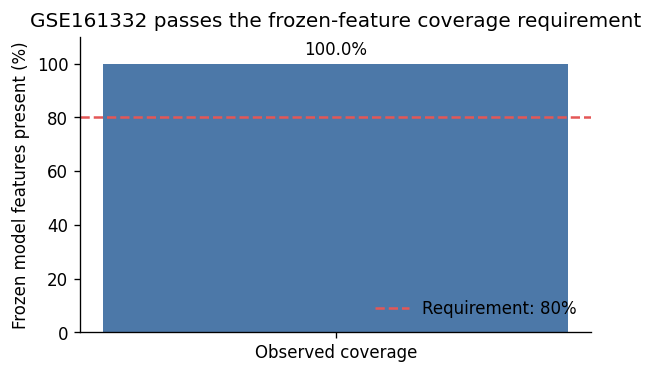

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
coverage_pct = summary["feature_coverage"] * 100
requirement_pct = summary["coverage_requirement"] * 100
ax.bar(["Observed coverage"], [coverage_pct], color="#4C78A8")
ax.axhline(requirement_pct, color="#E45756", linestyle="--", linewidth=1.5, label=f"Requirement: {requirement_pct:.0f}%")
ax.set_ylim(0, 110)
ax.set_ylabel("Frozen model features present (%)")
ax.set_title("GSE161332 passes the frozen-feature coverage requirement")
ax.text(0, coverage_pct + 2, f"{coverage_pct:.1f}%", ha="center", va="bottom")
ax.legend(frameon=False, loc="lower right")
plt.show()

## Model Agreement and Consensus Acceptance

The frozen decision rule is intentionally conservative:

1. logistic regression and random forest must predict the same label;
2. both model confidences must be at least `0.60`;
3. feature coverage must be at least `80%`;
4. otherwise the cell is labeled `ambiguous`.

In [4]:
acceptance_summary = pd.DataFrame(
    [
        {
            "metric": "model_agreement_rate",
            "n_cells": summary["n_models_agree"],
            "fraction": summary["model_agreement_rate"],
        },
        {
            "metric": "consensus_acceptance_rate",
            "n_cells": summary["n_consensus_accepted"],
            "fraction": summary["consensus_acceptance_rate"],
        },
    ]
)
acceptance_summary["percent"] = acceptance_summary["fraction"] * 100
acceptance_summary

,metric,n_cells,fraction,percent
0,model_agreement_rate,5597,0.888413,88.841270
1,consensus_acceptance_rate,1987,0.315397,31.539683


/var/folders/w0/v9yy8dh97l5cbw6kwc8v949m0000gn/T/ipykernel_48798/427927919.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Model agreement", "Accepted consensus"], rotation=0)


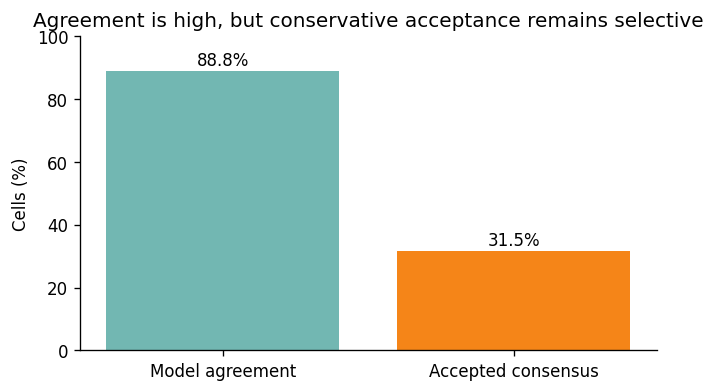

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
plot_df = acceptance_summary.copy()
ax.bar(plot_df["metric"], plot_df["percent"], color=["#72B7B2", "#F58518"])
ax.set_ylim(0, 100)
ax.set_ylabel("Cells (%)")
ax.set_title("Agreement is high, but conservative acceptance remains selective")
ax.set_xticklabels(["Model agreement", "Accepted consensus"], rotation=0)
for i, row in plot_df.iterrows():
    ax.text(i, row["percent"] + 2, f"{row['percent']:.1f}%", ha="center")
plt.show()

## Consensus Prediction Distribution

This is the main biological result of the root-derived model on the leaf reference.

In [6]:
if COUNTS_PATH.exists():
    consensus_counts = pd.read_csv(COUNTS_PATH)
else:
    consensus_counts = (
        pd.Series(summary["consensus_counts"], name="n_cells")
        .rename_axis("consensus_prediction")
        .reset_index()
    )
    consensus_counts["fraction"] = consensus_counts["n_cells"] / summary["n_cells"]

consensus_counts = consensus_counts.sort_values("n_cells", ascending=False).reset_index(drop=True)
consensus_counts["percent"] = consensus_counts["fraction"] * 100
consensus_counts

,consensus_prediction,n_cells,fraction,percent
0,ambiguous,4313,0.684603,68.460317
1,abiotic_stress_response,1825,0.289683,28.968254
2,transport_interface_or_water_balance,155,0.024603,2.460317
3,proliferative_or_meristematic,7,0.001111,0.111111


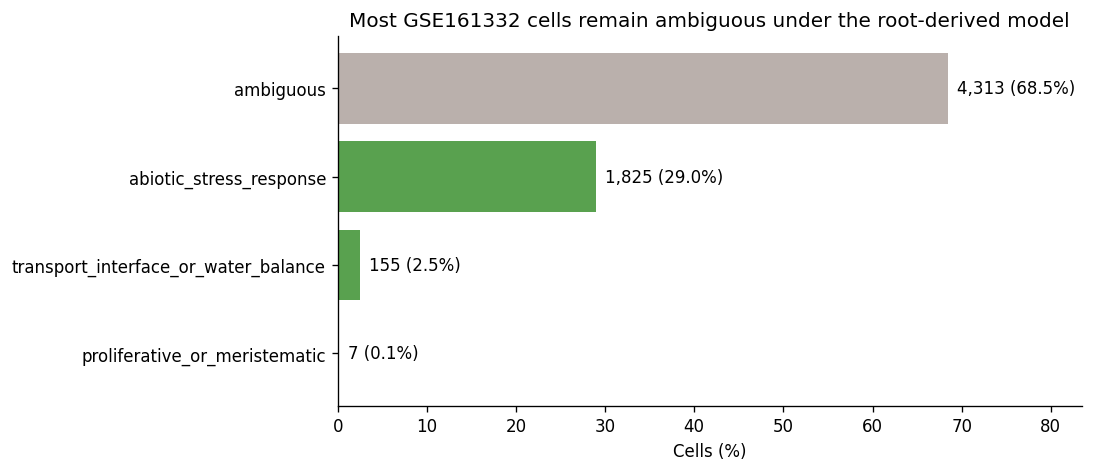

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#BAB0AC" if label == "ambiguous" else "#59A14F" for label in consensus_counts["consensus_prediction"]]
ax.barh(consensus_counts["consensus_prediction"], consensus_counts["percent"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Cells (%)")
ax.set_title("Most GSE161332 cells remain ambiguous under the root-derived model")
for i, row in consensus_counts.iterrows():
    ax.text(row["percent"] + 1, i, f"{row['n_cells']:,} ({row['percent']:.1f}%)", va="center")
ax.set_xlim(0, max(consensus_counts["percent"]) + 15)
plt.show()

## Individual Model Behavior

The individual classifiers agree for most cells, but their confidence profiles differ. The random forest median confidence is below the `0.60` acceptance threshold, which contributes to many ambiguous calls even when the two models choose the same broad label.

In [8]:
individual_counts = pd.DataFrame(summary["individual_model_counts"]).fillna(0).astype(int)
individual_counts["logistic_fraction"] = individual_counts["logistic"] / summary["n_cells"]
individual_counts["random_forest_fraction"] = individual_counts["random_forest"] / summary["n_cells"]
individual_counts

,logistic,random_forest,logistic_fraction,random_forest_fraction
abiotic_stress_response,5907,5381,0.937619,0.854127
transport_interface_or_water_balance,280,900,0.044444,0.142857
proliferative_or_meristematic,113,19,0.017937,0.003016


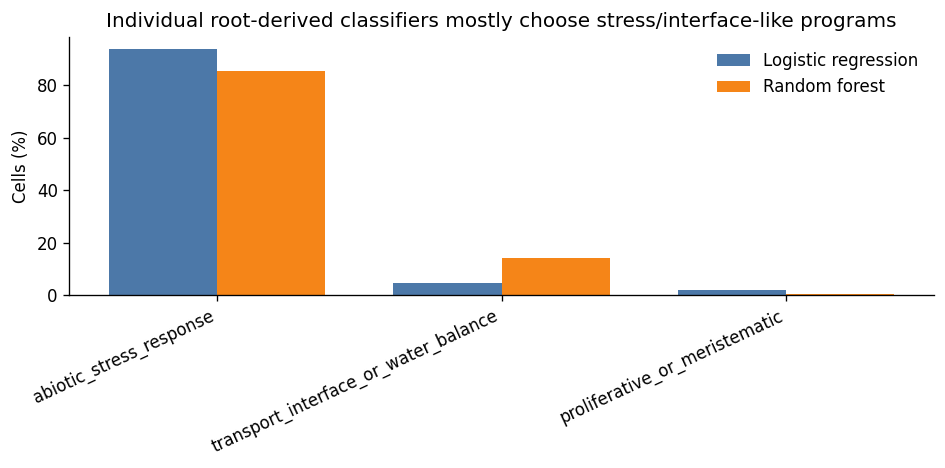

In [9]:
plot_df = individual_counts[["logistic", "random_forest"]].reset_index(names="program")
plot_long = plot_df.melt(id_vars="program", var_name="model", value_name="n_cells")
plot_long["percent"] = plot_long["n_cells"] / summary["n_cells"] * 100

fig, ax = plt.subplots(figsize=(8, 4))
programs = plot_df["program"].tolist()
x = range(len(programs))
width = 0.38
log_vals = plot_long[plot_long["model"] == "logistic"].set_index("program").loc[programs, "percent"]
rf_vals = plot_long[plot_long["model"] == "random_forest"].set_index("program").loc[programs, "percent"]
ax.bar([i - width / 2 for i in x], log_vals, width=width, label="Logistic regression", color="#4C78A8")
ax.bar([i + width / 2 for i in x], rf_vals, width=width, label="Random forest", color="#F58518")
ax.set_xticks(list(x))
ax.set_xticklabels(programs, rotation=25, ha="right")
ax.set_ylabel("Cells (%)")
ax.set_title("Individual root-derived classifiers mostly choose stress/interface-like programs")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Optional Full Reproduction

The cell below reruns the full local script only if the required ignored data/model files are present and `RUN_FULL_ANALYSIS` is set to `True`. It is disabled by default so the notebook can execute cleanly on GitHub or a fresh clone without large local files.

In [10]:
RUN_FULL_ANALYSIS = False

required_paths = [
    REPO_ROOT / "data/public_references/raw/GSE161332/GSE161332_matrix.mtx.gz",
    REPO_ROOT / "data/public_references/raw/GSE161332/GSE161332_features.tsv.gz",
    REPO_ROOT / "data/public_references/raw/GSE161332/GSE161332_barcodes.tsv.gz",
    REPO_ROOT / "results/root_reference_consensus_ortholog_restricted/logistic_regression_root_consensus.joblib",
    REPO_ROOT / "results/root_reference_consensus_ortholog_restricted/random_forest_root_consensus.joblib",
]
missing_paths = [path for path in required_paths if not path.exists()]

if RUN_FULL_ANALYSIS and not missing_paths:
    import subprocess
    completed = subprocess.run(
        ["python", "scripts/33_apply_root_consensus_to_gse161332_leaf.py"],
        cwd=REPO_ROOT,
        check=True,
        text=True,
        capture_output=True,
    )
    print(completed.stdout)
elif RUN_FULL_ANALYSIS and missing_paths:
    print("Full rerun requested, but these files are missing:")
    for path in missing_paths:
        print(f"- {path}")
else:
    print("Full rerun skipped. Set RUN_FULL_ANALYSIS = True when local data/model artifacts are available.")

Full rerun skipped. Set RUN_FULL_ANALYSIS = True when local data/model artifacts are available.


## Conclusions

1. **GSE161332 is technically usable for this project.** All `340` frozen root-consensus features are present, so the feature-space compatibility problem is solved for this leaf matrix.

2. **The current root-derived model is intentionally conservative on leaf data.** It accepts only `31.5%` of cells under the dual-model agreement rule and leaves `68.5%` as `ambiguous`.

3. **The accepted predictions are dominated by stress/interface-like labels.** This is expected because the frozen v1 model predicts only three root-derived broad programs and does not yet include leaf-specific programs such as photosynthetic/mesophyll or epidermal/surface identity.

4. **The result supports the next project step.** We should keep the root-derived model as a conservative benchmark, but build a dedicated `GSE161332` leaf/aerial reference layer to score or classify photosynthetic, mesophyll-like, epidermal/surface, guard-cell-like, and vascular/transport programs before interpreting Wolffia single-cell data.